In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
# plt.rcParams["axes.linewidth"] = 1.2
# plt.rcParams["xtick.major.width"] = 1.2
# plt.rcParams["ytick.major.width"] = 1.2
# plt.rcParams["font.size"] = 12
# plt.rcParams["axes.titlesize"] = 12
# plt.rcParams["axes.labelsize"] = 12
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = "DejaVu Sans"
# plt.rcParams["figure.figsize"] = (6,4)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "lines.linewidth": 1.8,

    "legend.fontsize": 9,
})

root_dir = "./definitive"

def get_array(dataset, estimator, key):
    try:
        filepath = os.path.join(root_dir, dataset, "results_{}_{}.npz".format(dataset, estimator))
        arr = np.load(filepath, allow_pickle = True)
        arr = arr[key]
        if key == "mse" or key == "oracle":
            arr = np.sqrt(arr)
        return arr
    except:
        raise Exception(FileNotFoundError)

def statistics(arr):
    return np.mean(arr, axis = 0), np.std(arr, axis = 0, ddof = 1)

def get_statistics_from_dataset(dataset, estimator, key):
    arr = get_array(dataset, estimator, key)
    return statistics(arr)

def create_canvas(n_estimators, n_metrics):
    w = min(3.3*n_metrics, 14)
    h = min(2.4*n_estimators, 10)
    return plt.subplots(n_estimators, n_metrics, sharex="col", sharey="col", figsize=(w, h))

def get_all_estimators(dataset, estimators, key):
    data = {estimator: None for estimator in estimators}
    for estimator in estimators:
        if estimator == "linear":
           data[estimator] = get_array(dataset, estimator, key)
        else: 
            data[estimator] = get_statistics_from_dataset(dataset, estimator, key)
    return data

def smart_log_ticks(x, max_ticks=4):
    n = len(x)

    if n <= max_ticks:
        return x
    idx = np.linspace(0, n-1, max_ticks).astype(int)
    return x[idx]

def nice_ticks(y, nticks = 5, decimals=2):
    ymin = np.min(y)
    ymax = np.max(y)
    ticks = np.linspace(ymin, ymax, nticks)
    span = ymax - ymin
    decimals = 2 if span < 1 else 1

    ticks = np.round(ticks, decimals)
    ticks[0] = np.round(ymin, decimals)
    ticks[-1] = np.round(ymax, decimals)

    ticks = np.unique(ticks)
    return ticks


In [2]:
from matplotlib.ticker import FormatStrFormatter
def plot_dataset_results(dataset, estimators_dict, metrics_dict, colors_dict, saving_path):

    n_estimators = len(estimators_dict)
    n_metrics = len(metrics_dict)

    estimators = list(estimators_dict.keys())
    metrics = list(metrics_dict.keys())

    x = get_array(dataset, estimators[0], "x")
    x_ticks = smart_log_ticks(x)
    fig, ax = create_canvas(n_estimators, n_metrics)
    for a in ax[:-1, :].flat:
        a.tick_params(labelbottom = False)
    
    for j, metric in enumerate(metrics):

        data = get_all_estimators(dataset, estimators, metric)

        # ---------- calcular rango global de R² ----------
        if metric == "r2":
            r2_means = []
            r2_stds = []
            for estimator in estimators:
                if estimator != "linear":
                    r2_means.append(data[estimator][0])
                    r2_stds.append(data[estimator][1])
                else:
                    r2_means.append(data[estimator].squeeze(0))
                    r2_stds.append(np.zeros_like(data[estimator].squeeze(0)))
            means = np.concatenate(r2_means)
            stds = np.concatenate(r2_stds)
            lower = means - stds
            upper = means + stds

            y_min = max(0, lower.min())
            y_max = min(1, upper.max())

            margin = 0.05 * (y_max - y_min)
            
            y_for_ticks = np.concatenate([lower, upper])
        else:
            all_vals = []
            for estimator in estimators:
                if estimator != "linear":
                    mean, std = data[estimator]
                    all_vals.append(mean - std)
                    all_vals.append(mean + std)
                else:
                    all_vals.append(data[estimator].squeeze(0))
                y_for_ticks = np.concatenate(all_vals)
        if metric in ["mse", "mi", "max_riv", "oracle"]:
            y_for_ticks = np.maximum(0, y_for_ticks)
        elif metric == "r2":
            y_for_ticks = np.clip(y_for_ticks, 0, 1)
        if metric == "r2":
            y_ticks = nice_ticks(y_for_ticks, nticks=4)
        else:
            y_ticks = nice_ticks(y_for_ticks, nticks=5)
        # ---------- plotting ----------
        for i, estimator in enumerate(estimators):

            if estimator != "linear":

                mean, std = data[estimator]

                lower = mean - std
                upper = mean + std

                if metric in ["mse", "mi", "max_riv", "oracle"]:
                    lower = np.maximum(0, lower)

                if metric == "r2":
                    upper = np.minimum(1, upper)

                ax[i, j].plot(x, mean, color=colors_dict[metric], linewidth = 1.8)

                ax[i, j].fill_between(
                    x,
                    lower,
                    upper,
                    #alpha=0.1 if metric in ["mi", "max_riv"] else 0.2,
                    alpha = 0.15,
                    linewidth = 0,
                    color=colors_dict[metric]
                )

            else:

                ax[i, j].plot(
                    x,
                    data[estimator].squeeze(0),
                    color=colors_dict[metric]
                )

            # ---------- líneas de referencia ----------
            if metric in ["oracle", "max_riv", "mi"]:
                ax[i, j].axhline(0, linestyle="--", linewidth=1.2, color="black", alpha=0.6)

            # ---------- límites R² ----------
            if metric == "r2":
                ax[i, j].set_ylim(y_min - margin, y_max + margin)

            # ---------- etiquetas ----------
            if j == 0:
                ax[i, j].set_ylabel(estimators_dict[estimator])

            if i == 0:
                ax[i, j].set_title(metrics_dict[metric])

            if i == n_estimators - 1:
                ax[i, j].set_xlabel("Training Samples")
                ax[i, j].set_xlim(x[0], x[-1])

            ax[i, j].set_xscale("log")
            
            ax[i, j].set_yticks(y_ticks)

            ax[i, j].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

            ax[i,j].set_xticks(x_ticks)
            ax[i,j].get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax[i,j].ticklabel_format(style="plain", axis="x")

            ax[i,j].minorticks_off()
            ax[i, j].grid(True, alpha=0.25,linewidth=0.5, linestyle = "--")
            for spine in ["top", "right"]:
                ax[i,j].spines[spine].set_visible(False)

    fig.subplots_adjust(wspace=0.2, hspace=0.25, left=0.08, right=0.98, bottom=0.08, top=0.93)
    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    # para paper, quitarlo para tesis
    fig.set_size_inches(7.2, 4.5)
    fig.savefig(saving_path, dpi=300, bbox_inches="tight")

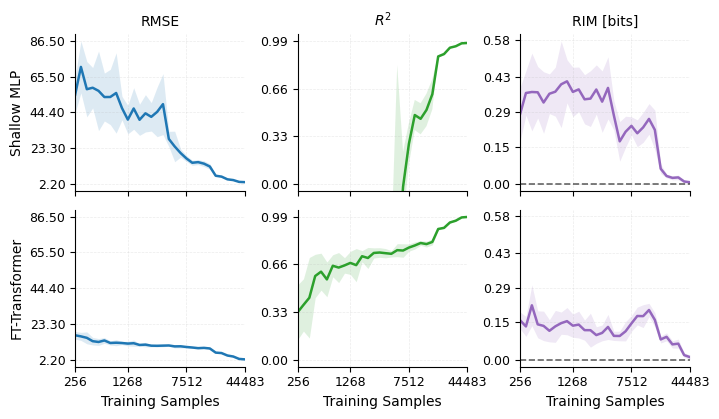

In [4]:
# POSTER --- PLOT 1

path_root = "./definitive_plots"
colors_dict = {
    "mse": "#1f77b4",   # azul
    "r2": "#2ca02c",     # verde
    "mi": "#d62728",     # rojo
    "max_riv": "#9467bd" # morado
}
metrics_dict = {"mse": "RMSE", "r2": "$R^2$", "max_riv": "RIM [bits]"}
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer"}

plot_dataset_results("sarcos", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "sarcos_results_poster.pdf"))

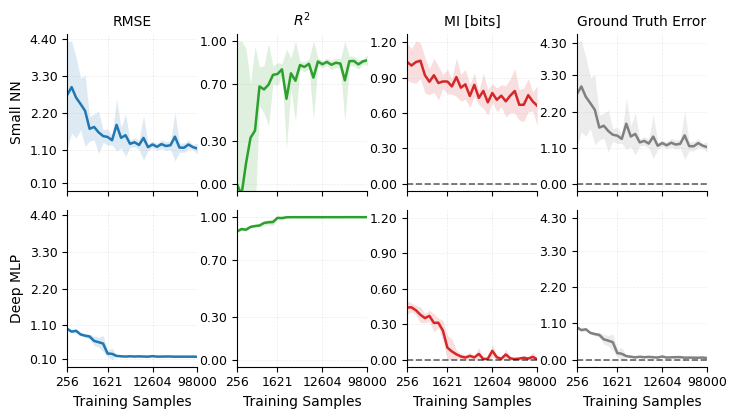

In [10]:
# POSTER --- PLOT 2

path_root = "./definitive_plots"
colors_dict = {
    "mse": "#1f77b4",   # azul
    "r2": "#2ca02c",     # verde
    "mi": "#d62728",     # rojo
    "oracle": "grey"
}
metrics_dict = {"mse": "RMSE", "r2": "$R^2$", "mi": "MI [bits]", "oracle": "Ground Truth Error"}
estimators_dict = {"small": "Small NN", "deep": "Deep MLP"}

plot_dataset_results("tanh_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "tanh_results_poster.pdf"))

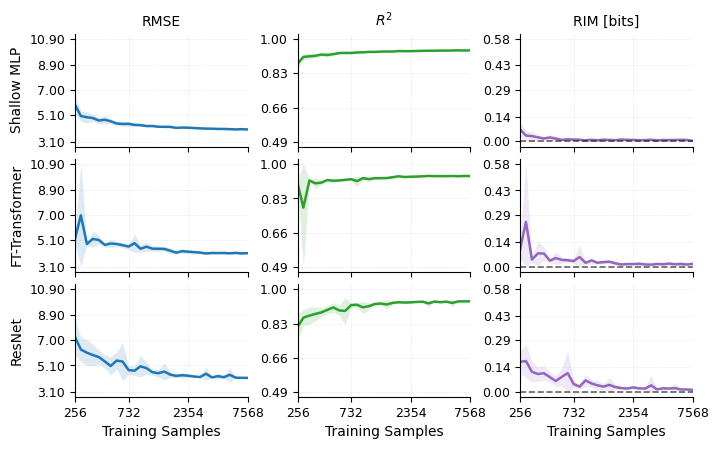

In [3]:
path_root = "./definitive_plots" 
colors_dict = {
    "mse": "#1f77b4",   # azul
    "r2": "#2ca02c",     # verde
    "mi": "#d62728",     # rojo
    "max_riv": "#9467bd" # morado
}
metrics_dict = {"mse": "RMSE", "r2": "$R^2$", "max_riv": "RIM [bits]"}#, "mi":"Mutual Information [bits]"}
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet"}#{"decision_tree": "Decision Tree", 

plot_dataset_results("ccpp", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "ccpp_results.pdf"))

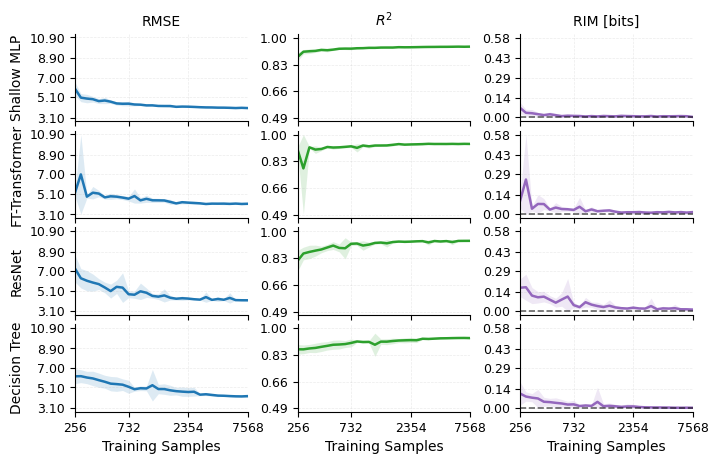

In [4]:
path_root = "./definitive_plots" 
colors_dict = {
    "mse": "#1f77b4",   # azul
    "r2": "#2ca02c",     # verde
    "mi": "#d62728",     # rojo
    "max_riv": "#9467bd" # morado
}
metrics_dict = {"mse": "RMSE", "r2": "$R^2$", "max_riv": "RIM [bits]"}#, "mi":"Mutual Information [bits]"}
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet", "decision_tree": "Decision Tree",}

plot_dataset_results("ccpp", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "ccpp_results_thesis.pdf"))

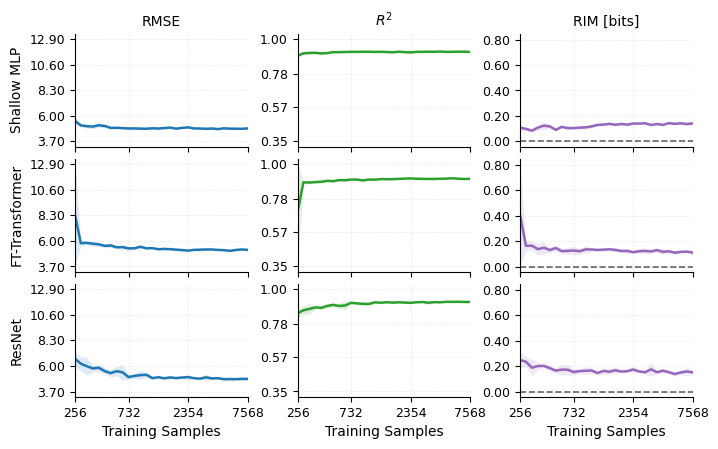

In [5]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet",}
plot_dataset_results("noisy_ccpp", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "unfavorable_ccpp_results.pdf"))

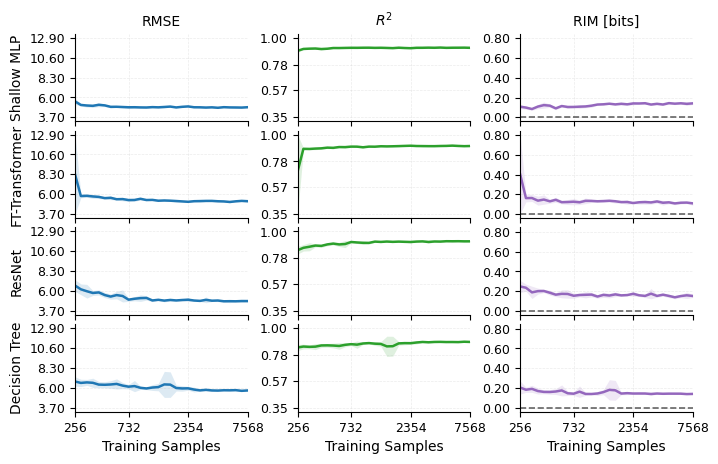

In [6]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet", "decision_tree": "Decision Tree",}
plot_dataset_results("noisy_ccpp", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "unfavorable_ccpp_results_thesis.pdf"))

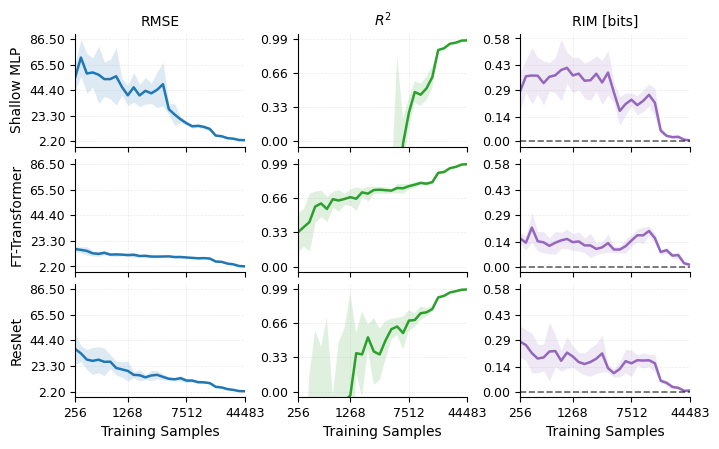

In [7]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet",}
plot_dataset_results("sarcos", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "sarcos_results.pdf"))

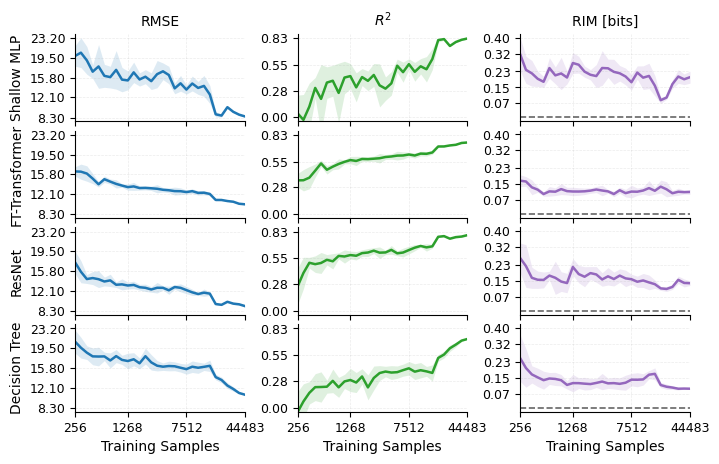

In [8]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet", "decision_tree": "Decision Tree",}
plot_dataset_results("unfavorable_sarcos", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "unfavorable_sarcos_results_thesis.pdf"))

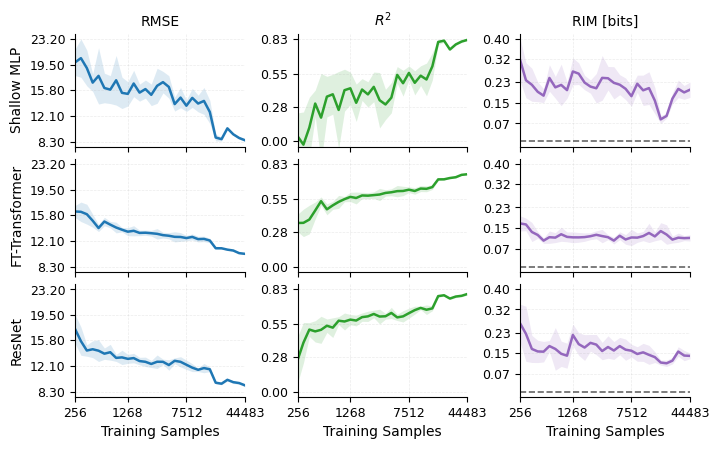

In [9]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet"}
plot_dataset_results("unfavorable_sarcos", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "unfavorable_sarcos_results.pdf"))

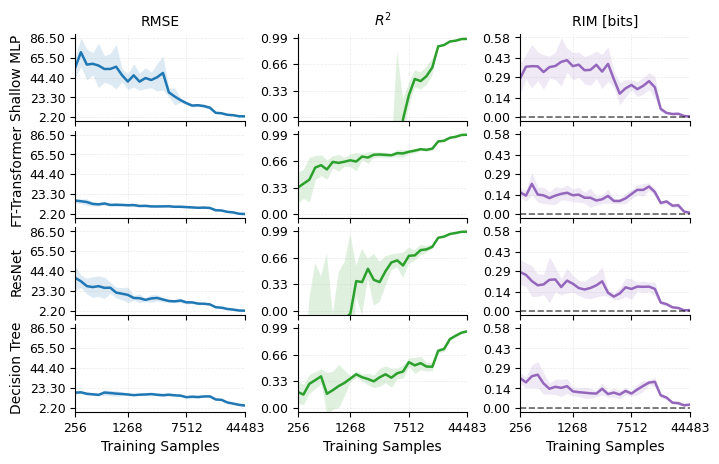

In [10]:
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet", "decision_tree": "Decision Tree",}
plot_dataset_results("sarcos", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "sarcos_results_thesis.pdf"))

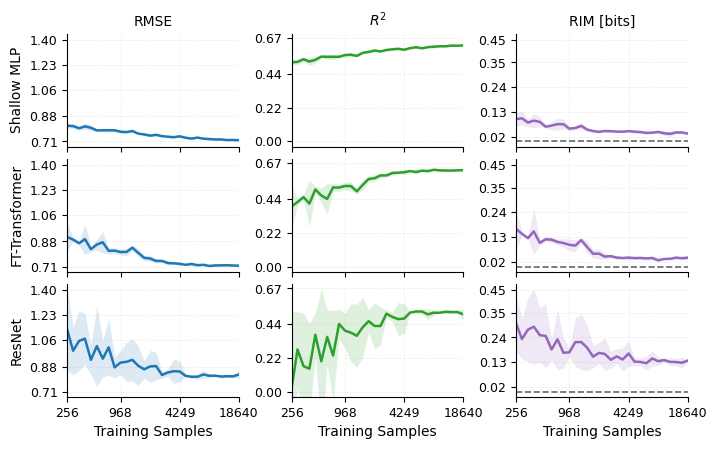

In [11]:
#reduced housing

#metrics_dict = {"mse": "RMSE", "r2": "$R^2$", "max_riv": "Residual Information Metric [bits]", "mi":"Mutual Information [bits]"}
estimators_dict = {"shallow": "Shallow MLP", "transformer": "FT-Transformer", "resnet":"ResNet"}
plot_dataset_results("reduced_housing", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "reduced_housing_results.pdf"))

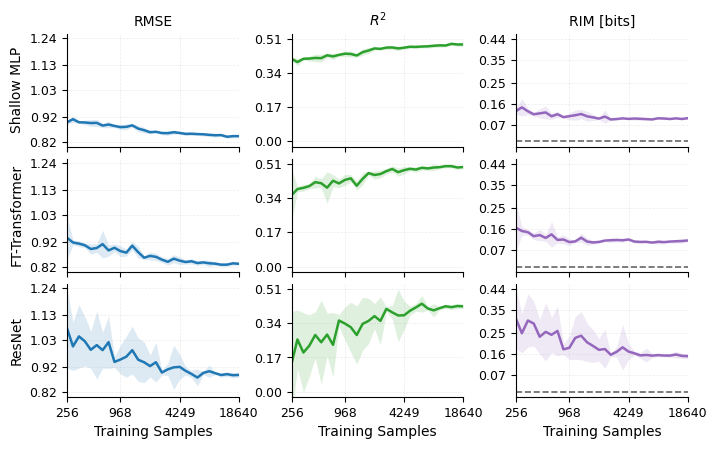

In [12]:
plot_dataset_results("unfavorable_housing", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "unfavorable_housing_reduced_results.pdf"))

#### Synthetic Data

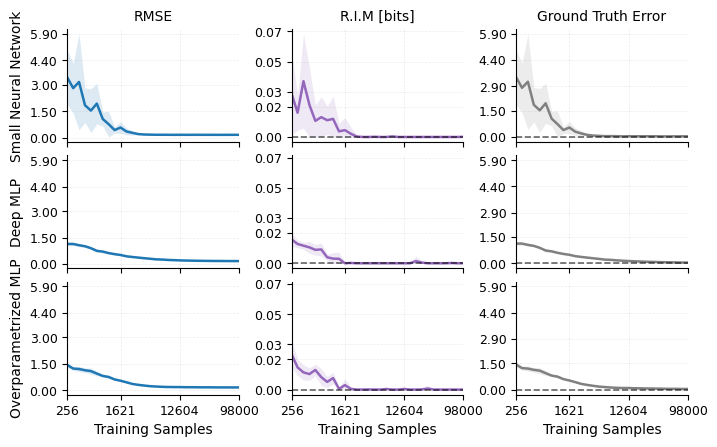

In [13]:
colors_dict["oracle"] = "gray"
metrics_dict = {"mse": "RMSE", "max_riv": "R.I.M [bits]", "oracle": "Ground Truth Error"}
estimators_dict = {"small": "Small Neural Network", "deep": "Deep MLP", "overparametrized": "Overparametrized MLP"}
plot_dataset_results("linear_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "linear_results.pdf"))

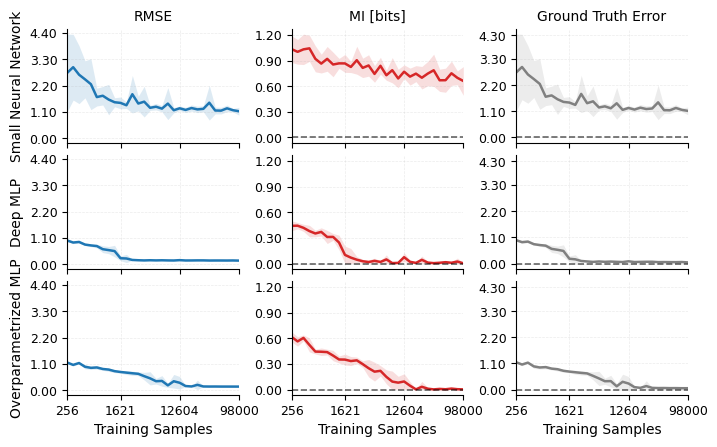

In [14]:
metrics_dict = {"mse": "RMSE", "mi": "MI [bits]", "oracle": "Ground Truth Error"}
estimators_dict = {"small": "Small Neural Network", "deep": "Deep MLP", "overparametrized": "Overparametrized MLP"}
plot_dataset_results("tanh_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "tanh_results.pdf"))                                         

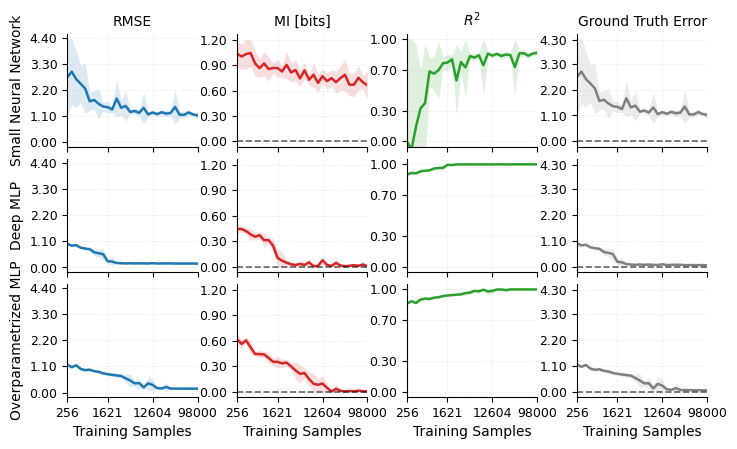

In [15]:
colors_dict["oracle"] = "gray"
metrics_dict = {"mse": "RMSE", "mi": "MI [bits]", "r2":"$R^2$","oracle": "Ground Truth Error"}
estimators_dict = {"small": "Small Neural Network", "deep": "Deep MLP", "overparametrized": "Overparametrized MLP"}
plot_dataset_results("tanh_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "tanh_results_thesis.pdf"))  

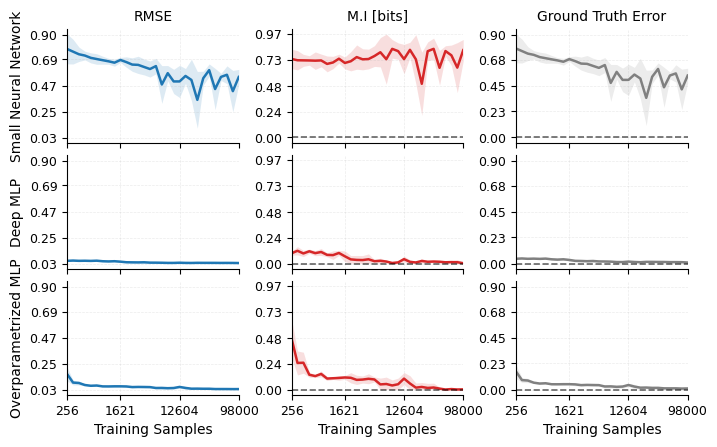

In [16]:
metrics_dict = {"mse": "RMSE", "mi": "M.I [bits]","oracle": "Ground Truth Error"}
plot_dataset_results("sin_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "sin_results.pdf"))                                         

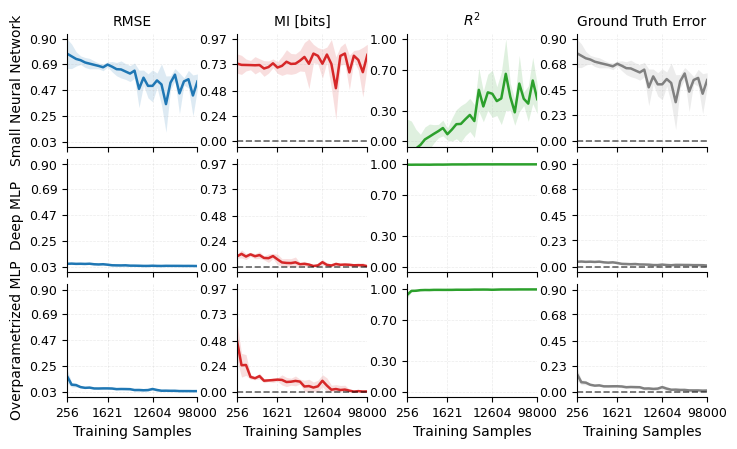

In [17]:
metrics_dict = {"mse": "RMSE", "mi": "MI [bits]", "r2":"$R^2$","oracle": "Ground Truth Error"}
plot_dataset_results("sin_easy", estimators_dict, metrics_dict, colors_dict, saving_path=os.path.join(path_root, "sin_results_thesis.pdf")) 

### Early - Stopping

In [24]:
root_dir_es = "./experiments/early_stopping/"
mode = "vanilla"
max_riv_val = np.load("{}max_riv_{}_val.npy".format(root_dir_es,mode), allow_pickle = True)
rmse_val = np.load("{}rmse_{}_val.npy".format(root_dir_es,mode), allow_pickle = True)
rmse_train = np.load("{}rmse_{}_train.npy".format(root_dir_es,mode), allow_pickle = True)
riv_full_val = np.load("{}riv_full_{}_val.npy".format(root_dir_es, mode), allow_pickle=True)

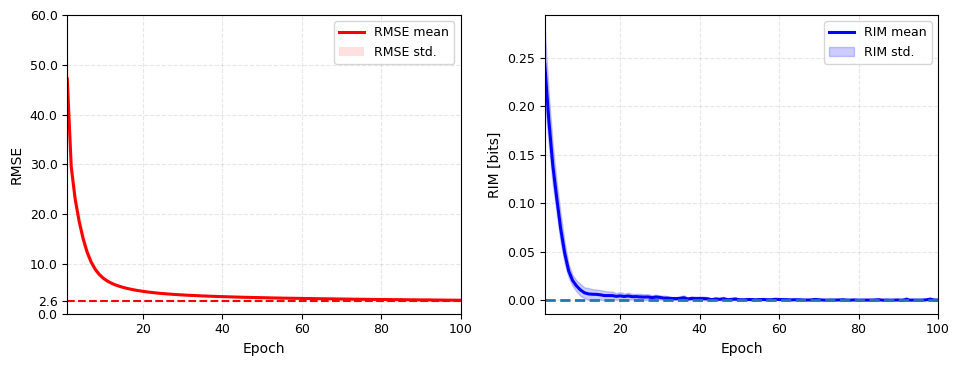

In [25]:
# Mutual Information
epochs = range(1, 101)
max_riv_val_mean, max_riv_val_std = statistics(max_riv_val)
rmse_val_mean, rmse_val_std = statistics(rmse_val)

fig, ax = plt.subplots(nrows=1, ncols=2, sharex="row", figsize=(10, 4))
ax[1].plot(epochs, max_riv_val_mean, linewidth= 2.2, color="blue", label="RIM mean")
ax[1].fill_between(epochs, np.maximum(0,max_riv_val_mean - max_riv_val_std), max_riv_val_mean + max_riv_val_std, color="blue", alpha=0.2, label="RIM std.")
ax[1].legend()
ax[0].plot(epochs, rmse_val_mean, linewidth= 2.2, color = "red", label="RMSE mean")
ax[0].fill_between(epochs, np.maximum(0, rmse_val_mean - rmse_val_std), rmse_val_mean + rmse_val_std, color="red", alpha=0.12, linewidth=0, label="RMSE std.")
ax[0].legend()
ax[0].set_xlim(1, 100)
ax[0].axhline(np.min(rmse_val), linewidth=1.5, linestyle= "--", color="red")
ax[1].axhline(0.0, linestyle = "--", linewidth=2)
ax[0].grid(linestyle="--", alpha=0.3)
ax[1].grid(linestyle="--", alpha=0.3)
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")


# Si prefieres mantener los ticks originales y solo añadir el mínimo
min_rmse = np.min(rmse_val)
min_rim = np.min(max_riv_val)

# Para RMSE
yticks_rmse = ax[0].get_yticks()
yticks_rmse = np.append(yticks_rmse, min_rmse)
yticks_rmse = np.unique(np.round(yticks_rmse, decimals=4))  # Redondear para evitar duplicados
ax[0].set_yticks(yticks_rmse)


ax[1].set_ylabel("RIM [bits]")
fig.subplots_adjust(wspace=0.25, hspace=0.35, left=0.08, right=0.98, bottom=0.08, top=0.93)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
fig.savefig("./definitive_plots/favorable_case_training.pdf")

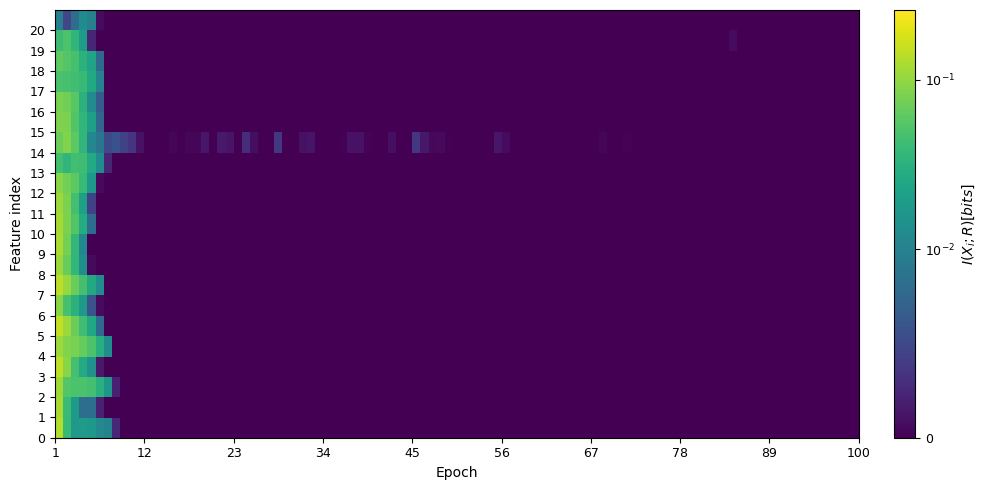

In [26]:
from matplotlib.colors import SymLogNorm
mi_plot = np.maximum(riv_full_val[0],0.0)
order = np.argsort(-mi_plot.max(axis=1))
mi_plot = mi_plot[order]
fig, ax = plt.subplots(figsize = (10,5))
im = ax.imshow(mi_plot, aspect="auto", origin="lower", extent=[0, 100, 0, 21],norm=SymLogNorm(vmin=0.0, vmax=np.max(mi_plot), linthresh=0.01, base=10), cmap="viridis")
cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label(label=r"$I(X_i;R) [bits]$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Feature index")
#ax.set_title('Marginal feature analysis for R.I.M.')

# ticks más limpios
ax.set_xlim(1, 100)
ax.set_xticks(np.linspace(1, mi_plot.shape[1], 10, dtype=int))
ax.set_yticks(np.linspace(0, mi_plot.shape[0]-1, 21, dtype=int))

plt.tight_layout()
plt.savefig("./definitive_plots/favorable_case_rim_evolution.pdf")
plt.show()

In [27]:
mode = "overfitting"
max_riv_val_over = np.load("{}max_riv_{}_val.npy".format(root_dir_es,mode), allow_pickle = True)
rmse_val_over = np.load("{}rmse_{}_val.npy".format(root_dir_es,mode), allow_pickle = True)
rmse_train_over = np.load("{}rmse_{}_train.npy".format(root_dir_es,mode), allow_pickle = True)
riv_full_val_over = np.load("{}riv_full_{}_val.npy".format(root_dir_es, mode), allow_pickle=True)

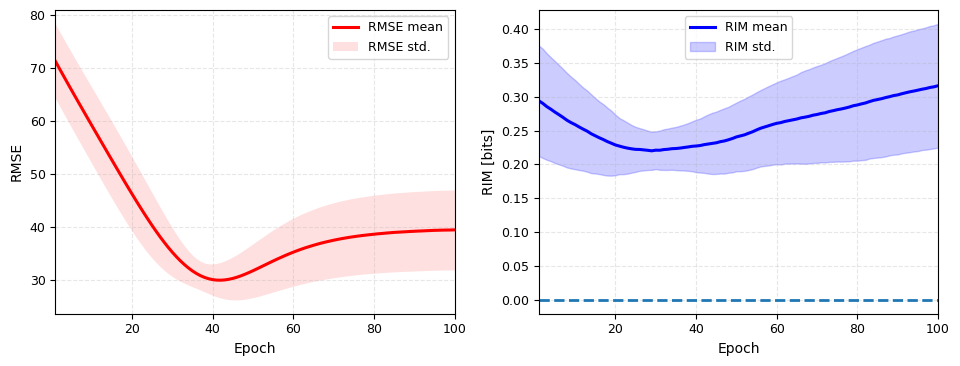

In [28]:
# Mutual Information
epochs = range(1, 101)
max_riv_val_mean, max_riv_val_std = statistics(max_riv_val_over)
rmse_val_mean, rmse_val_std = statistics(rmse_val_over)

fig, ax = plt.subplots(nrows=1, ncols=2, sharex="row", figsize=(10, 4))
ax[1].plot(epochs, max_riv_val_mean, linewidth= 2.2, color="blue", label="RIM mean")
ax[1].fill_between(epochs, np.maximum(0,max_riv_val_mean - max_riv_val_std), max_riv_val_mean + max_riv_val_std, color="blue", alpha=0.2, label="RIM std.")
ax[1].legend()
ax[0].plot(epochs, rmse_val_mean, linewidth= 2.2, color = "red", label="RMSE mean")
ax[0].fill_between(epochs, np.maximum(0, rmse_val_mean - rmse_val_std), rmse_val_mean + rmse_val_std, color="red", alpha=0.12, linewidth=0, label="RMSE std.")
ax[0].legend()
ax[0].set_xlim(1, 100)
ax[1].axhline(0.0, linestyle = "--", linewidth=2)
ax[0].grid(linestyle="--", alpha=0.3)
ax[1].grid(linestyle="--", alpha=0.3)
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[1].set_ylabel("RIM [bits]")
fig.subplots_adjust(wspace=0.25, hspace=0.35, left=0.08, right=0.98, bottom=0.08, top=0.93)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
fig.savefig("./definitive_plots/overfitting_case_training.pdf")

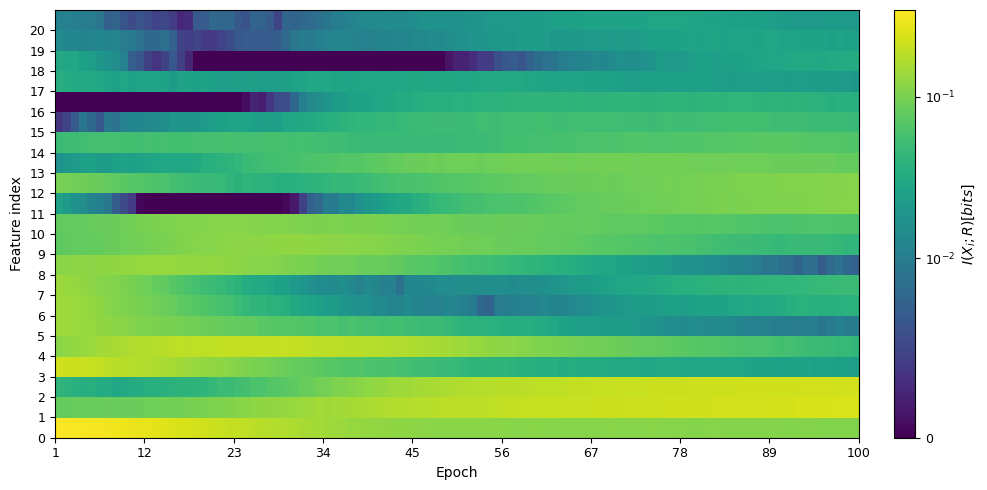

In [29]:
mi_plot = np.maximum(riv_full_val_over[0],0.0)
order = np.argsort(-mi_plot.max(axis=1))
mi_plot = mi_plot[order]
fig, ax = plt.subplots(figsize = (10,5))
im = ax.imshow(mi_plot, aspect="auto", origin="lower", extent=[0, 100, 0, 21], norm=SymLogNorm(vmin=0.0, vmax=np.max(mi_plot), linthresh=0.01, base=10), cmap="viridis")
cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label(label=r"$I(X_i;R) [bits]$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Feature index")
#ax.set_title('Marginal feature analysis for R.I.M.')
ax.set_xlim(1, 100)
# ticks más limpios
ax.set_xticks(np.linspace(1, mi_plot.shape[1], 10, dtype=int))
ax.set_yticks(np.linspace(0, mi_plot.shape[0]-1, 21, dtype=int))

plt.tight_layout()
plt.savefig("./definitive_plots/overfitting_case_rim_evolution.pdf")
plt.show()